In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split, KFold
import torch
import torch.nn as nn
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset
import time
from torchmetrics.classification import BinaryAccuracy
from ignite.engine import Engine, Events
from ignite.handlers import EarlyStopping
from ignite.metrics import Loss, Accuracy

In [199]:
df_preprocessed = pd.read_csv('./df_preprocessed.csv', index_col=False)

In [200]:
df_shuffled = df_preprocessed.sample(frac=1).reset_index(drop=True)

X = df_shuffled.drop(columns=['target'])
y = df_shuffled['target']

In [201]:
# Oversampling
ros = RandomOverSampler(random_state=0)
X_resampled, y_resampled = ros.fit_resample(X, y)

In [202]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size = 0.1 , random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size = 0.11, random_state=42)

In [203]:
# Scale numerical variables
scaler = StandardScaler()
scaler.fit(X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_train[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_val[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_val[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_test[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_test[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])

In [204]:
# convert the DataFrame to PyTorch tensor
X_train = torch.tensor(X_train.values, dtype=torch.float32)
X_val = torch.tensor(X_val.values, dtype=torch.float32)
X_test = torch.tensor(X_test.values, dtype=torch.float32)
y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_val = torch.tensor(y_val.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [205]:
# original NN structure defined in Part I
class Net0(nn.Module):
    def __init__(self):
        super(Net0, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output

### Step1. Choose one hyperparameter to modify: number of layers

In [809]:
# hidden layer 1
class Net1(nn.Module):
    def __init__(self):
        super(Net1, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
    
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        output = self.sigmoid(x)
        return output

In [810]:
# hidden layer 3
class Net2(nn.Module):
    def __init__(self):
        super(Net2, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 88)
        self.elu3 = nn.ELU()
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(88, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.elu3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        output = self.sigmoid(x)
        return output

In [811]:
# hidden layer 4
class Net3(nn.Module):
    def __init__(self):
        super(Net3, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 88)
        self.elu3 = nn.ELU()
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(88, 104)
        self.elu4 = nn.ELU()
        self.dropout4 = nn.Dropout(0.3)

        self.fc5 = nn.Linear(104, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.elu3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.elu4(x)
        x = self.dropout4(x)

        x = self.fc5(x)
        output = self.sigmoid(x)
        return output

In [875]:
def train_test_model(model, optimizer, train_loader, val_loader, test_loader):
    accuracy_hist = []
    loss_hist = []
    accuracy_metric = BinaryAccuracy()
    best_loss = float('inf')
    PATH = "best_loss.pt"
    start_time = time.time()
    for epoch in range(10):
        model.train()
        train_loss = 0.0
        for train_inputs, train_labels in train_loader:
            optimizer.zero_grad()
            outputs = model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
  
        model.eval()
        test_loss = 0.0

        # validation
        model.eval()
        val_loss = 0.0
        val_accuracy_metric = BinaryAccuracy()
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_outputs = model(val_inputs)
                val_predicted = torch.round(val_outputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                val_accuracy_metric.update(val_predicted, val_labels)
        accuracy_hist.append(val_accuracy_metric.compute().item())
        loss_hist.append(val_loss/len(val_loader))
    
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), PATH)
    train_time = time.time() - start_time
    # test
    model.load_state_dict(torch.load(PATH, weights_only=True))
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            test_predicted = torch.round(test_outputs)
    
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            accuracy_metric.update(test_predicted, test_labels)

    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss / len(test_loader):.4f}, Training Time: {train_time:.4f}')
    return accuracy_hist, loss_hist


In [868]:
loss_function = nn.BCELoss()
train_dataset = TensorDataset(X_train, y_train.view(-1, 1))
train_loader = DataLoader(train_dataset, batch_size=4)
val_dataset = TensorDataset(X_val, y_val.view(-1, 1))
val_loader = DataLoader(val_dataset, batch_size=4)
test_dataset = TensorDataset(X_test, y_test.view(-1, 1))
test_loader = DataLoader(test_dataset, batch_size=4)
net0 = Net0()
net1 = Net1()
net2 = Net2()
net3 = Net3()
optimizer0 = optim.SGD(net0.parameters(), lr=0.001)
optimizer1 = optim.SGD(net1.parameters(), lr=0.001)
optimizer2 = optim.SGD(net2.parameters(), lr=0.001)
optimizer3 = optim.SGD(net3.parameters(), lr=0.001)

In [869]:
accuracy_hist0, loss_hist0 = train_test_model(net0, optimizer0, train_loader, val_loader, test_loader)

Accuracy: 0.7576, Test Loss: 0.5858


In [870]:
accuracy_hist1, loss_hist1 = train_test_model(net1, optimizer1, train_loader, val_loader, test_loader)

Accuracy: 0.7273, Test Loss: 0.5859


In [871]:
accuracy_hist2, loss_hist2 = train_test_model(net2, optimizer2, train_loader, val_loader, test_loader)

Accuracy: 0.7576, Test Loss: 0.6312


In [872]:
accuracy_hist3, loss_hist3 = train_test_model(net3, optimizer3, train_loader, val_loader, test_loader)

Accuracy: 0.6869, Test Loss: 0.6578


### Choose another hyperparameter: batch size

In [876]:
train_dataset1 = TensorDataset(X_train, y_train.view(-1, 1))
train_loader1 = DataLoader(train_dataset1, batch_size=2)
val_dataset1 = TensorDataset(X_val, y_val.view(-1, 1))
val_loader1 = DataLoader(val_dataset1, batch_size=2)
test_dataset1 = TensorDataset(X_test, y_test.view(-1, 1))
test_loader1 = DataLoader(test_dataset1, batch_size=2)
net0 = Net0()
optimizer0 = optim.SGD(net0.parameters(), lr=0.001)
accuracy_hist4, loss_hist4 = train_test_model(net0, optimizer0, train_loader1, val_loader1, test_loader1)

Accuracy: 0.7475, Test Loss: 0.5357, Training Time: 0.9750


In [877]:
train_dataset2 = TensorDataset(X_train, y_train.view(-1, 1))
train_loader2 = DataLoader(train_dataset2, batch_size=8)
val_dataset2 = TensorDataset(X_val, y_val.view(-1, 1))
val_loader2 = DataLoader(val_dataset2, batch_size=8)
test_dataset2 = TensorDataset(X_test, y_test.view(-1, 1))
test_loader2 = DataLoader(test_dataset2, batch_size=8)
net0 = Net0()
optimizer0 = optim.SGD(net0.parameters(), lr=0.001)
accuracy_hist5, loss_hist5 = train_test_model(net0, optimizer0, train_loader2, val_loader2, test_loader2)

Accuracy: 0.7172, Test Loss: 0.6337, Training Time: 0.3027


In [878]:
train_dataset3 = TensorDataset(X_train, y_train.view(-1, 1))
train_loader3 = DataLoader(train_dataset3, batch_size=12)
val_dataset3 = TensorDataset(X_val, y_val.view(-1, 1))
val_loader3 = DataLoader(val_dataset3, batch_size=12)
test_dataset3 = TensorDataset(X_test, y_test.view(-1, 1))
test_loader3 = DataLoader(test_dataset3, batch_size=12)
net0 = Net0()
optimizer0 = optim.SGD(net0.parameters(), lr=0.001)
accuracy_hist6, loss_hist6 = train_test_model(net0, optimizer0, train_loader3, val_loader3, test_loader3)

Accuracy: 0.7475, Test Loss: 0.6346, Training Time: 0.2255


### Choose another hyperparameter: learning rate

In [882]:
net0 = Net0()
optimizer4 = optim.SGD(net0.parameters(), lr=0.01)
accuracy_hist7, loss_hist7 = train_test_model(net0, optimizer4, train_loader, val_loader, test_loader)

Accuracy: 0.7879, Test Loss: 0.4706, Training Time: 0.5330


In [883]:
net0 = Net0()
optimizer5 = optim.SGD(net0.parameters(), lr=0.003)
accuracy_hist8, loss_hist8 = train_test_model(net0, optimizer5, train_loader, val_loader, test_loader)

Accuracy: 0.7879, Test Loss: 0.4934, Training Time: 0.5307


In [884]:
net0 = Net0()
optimizer6 = optim.SGD(net0.parameters(), lr=0.0005)
accuracy_hist9, loss_hist9 = train_test_model(net0, optimizer6, train_loader, val_loader, test_loader)

Accuracy: 0.7071, Test Loss: 0.6507, Training Time: 0.5389


### Choose another hyperparameter: dropout rate

In [227]:
# No dropout
class Net7(nn.Module):
    def __init__(self):
        super(Net7, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)

        x = self.fc2(x)
        x = self.elu2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output
# Dropout 0.1
class Net8(nn.Module):
    def __init__(self):
        super(Net8, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.1)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.1)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output
# Dropout 0.5
class Net9(nn.Module):
    def __init__(self):
        super(Net9, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.5)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output

In [228]:
net7 = Net7()
optimizer7 = optim.SGD(net7.parameters(), lr=0.001)
accuracy_hist10, loss_hist10 = train_test_model(net7, optimizer7, train_loader, val_loader, test_loader)

Accuracy: 0.7172, Test Loss: 0.5963


In [229]:
net8 = Net8()
optimizer8 = optim.SGD(net8.parameters(), lr=0.001)
accuracy_hist11, loss_hist11 = train_test_model(net8, optimizer8, train_loader, val_loader, test_loader)

Accuracy: 0.7071, Test Loss: 0.6102


In [230]:
net9 = Net9()
optimizer9 = optim.SGD(net9.parameters(), lr=0.001)
accuracy_hist12, loss_hist12 = train_test_model(net9, optimizer9, train_loader, val_loader, test_loader)

Accuracy: 0.7677, Test Loss: 0.5953


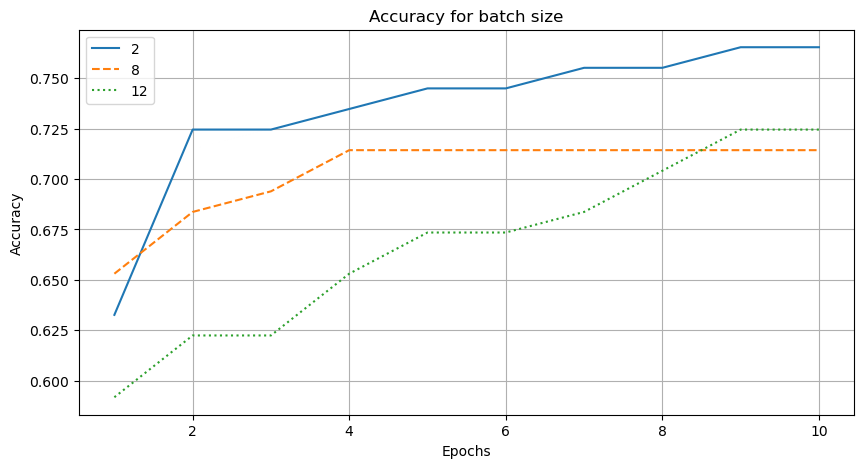

In [880]:
# Plot validation accuracies for each batch size
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), accuracy_hist4, label='2')
plt.plot(range(1, 11), accuracy_hist5, label='8', linestyle='--')
plt.plot(range(1, 11), accuracy_hist6, label='12', linestyle=':')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy for batch size')
plt.legend()
plt.grid(True)
plt.show()

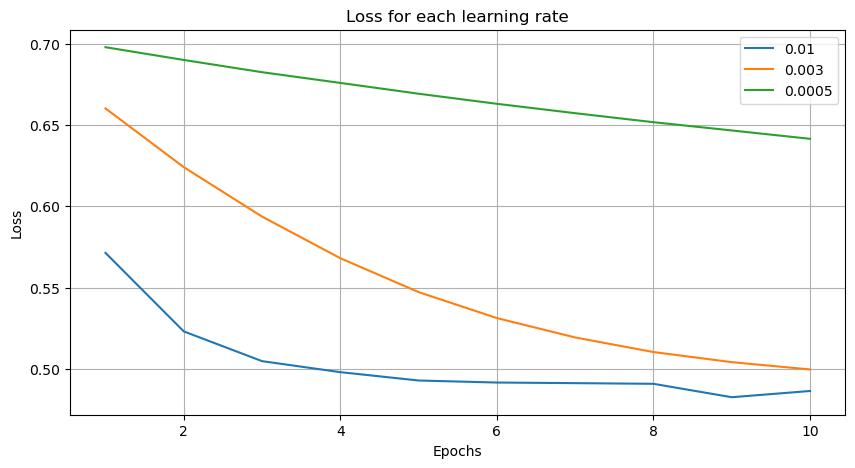

In [885]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), loss_hist7, label='0.01')
plt.plot(range(1, 11), loss_hist8, label='0.003')
plt.plot(range(1, 11), loss_hist9, label='0.0005')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss for each learning rate')
plt.legend()
plt.grid(True)
plt.show()

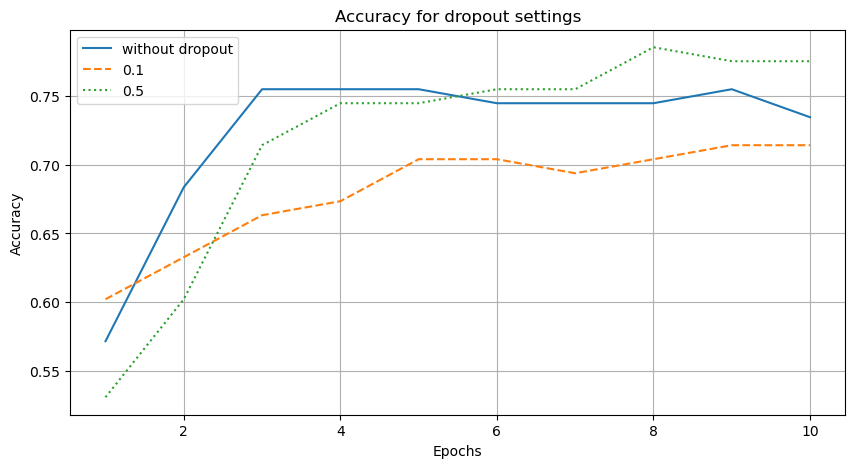

In [895]:
# Plot validation accuracies for each batch size
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), accuracy_hist10, label='without dropout')
plt.plot(range(1, 11), accuracy_hist11, label='0.1', linestyle='--')
plt.plot(range(1, 11), accuracy_hist12, label='0.5', linestyle=':')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy for dropout settings')
plt.legend()
plt.grid(True)
plt.show()

changed hyperparameters that returned the best results
- number of layers: 3(Accuracy 0.758)
- batch size: 2 (0.748)
- learning rate: 0.003 (0.788)
- droupout: 0.5 (0.768)

new base model
- learning rate: 0.003

1. Learning rate scheduler

In [886]:
def sch_train_test_model(sch_model, sch_optimizer, scheduler, train_loader, val_loader, test_loader):
    accuracy_metric = BinaryAccuracy()
    best_loss = float('inf')
    loss_hist = []
    accuracy_hist = []
    val_accuracy_metric = BinaryAccuracy()
    PATH = "best_loss.pt"
    start_time = time.time()
    for epoch in range(10):
        sch_model.train()
        train_loss = 0.0
        for train_inputs, train_labels in train_loader:
            sch_optimizer.zero_grad()
            outputs = sch_model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            sch_optimizer.step()
            train_loss += loss.item()
  
        sch_model.eval()
        test_loss = 0.0

        # validation
        sch_model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_outputs = sch_model(val_inputs)
                val_predicted = torch.round(val_outputs)
                val_loss += loss_function(val_outputs, val_labels).item()
                val_accuracy_metric.update(val_predicted, val_labels)
        accuracy_hist.append(val_accuracy_metric.compute().item())
        loss_hist.append(val_loss/len(val_loader))
        scheduler.step(val_loss)
        for param_group in sch_optimizer.param_groups:
            print(f"Epoch {epoch+1}, Learning Rate: {param_group['lr']}")
        print(f"Epoch {epoch+1}, Training Loss: {train_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(val_loader):.4f}")
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(sch_model.state_dict(), PATH)
    train_time = time.time() - start_time
    # test
    sch_model.load_state_dict(torch.load(PATH, weights_only=True))
    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = sch_model(test_inputs)
            test_predicted = torch.round(test_outputs)
    
            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            accuracy_metric.update(test_predicted, test_labels)

    print(f'Accuracy: {accuracy_metric.compute().item():.4f}, Test Loss: {test_loss / len(test_loader):.4f}, Train Time: {train_time:.4f}')
    return accuracy_hist, loss_hist

In [890]:
net0 = Net0()
new_optimizer = optim.SGD(net0.parameters(), lr=0.003)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(new_optimizer, 'min')
sch_accuracy_hist, sch_loss_hist = sch_train_test_model(net0, new_optimizer, scheduler, train_loader, val_loader, test_loader)

Epoch 1, Learning Rate: 0.003
Epoch 1, Training Loss: 0.6766, Validation Loss: 0.6579
Epoch 2, Learning Rate: 0.003
Epoch 2, Training Loss: 0.6440, Validation Loss: 0.6273
Epoch 3, Learning Rate: 0.003
Epoch 3, Training Loss: 0.6231, Validation Loss: 0.6005
Epoch 4, Learning Rate: 0.003
Epoch 4, Training Loss: 0.6053, Validation Loss: 0.5769
Epoch 5, Learning Rate: 0.003
Epoch 5, Training Loss: 0.5846, Validation Loss: 0.5565
Epoch 6, Learning Rate: 0.003
Epoch 6, Training Loss: 0.5680, Validation Loss: 0.5395
Epoch 7, Learning Rate: 0.003
Epoch 7, Training Loss: 0.5676, Validation Loss: 0.5278
Epoch 8, Learning Rate: 0.003
Epoch 8, Training Loss: 0.5584, Validation Loss: 0.5189
Epoch 9, Learning Rate: 0.003
Epoch 9, Training Loss: 0.5425, Validation Loss: 0.5105
Epoch 10, Learning Rate: 0.003
Epoch 10, Training Loss: 0.5421, Validation Loss: 0.5058
Accuracy: 0.7879, Test Loss: 0.4973, Train Time: 0.5299


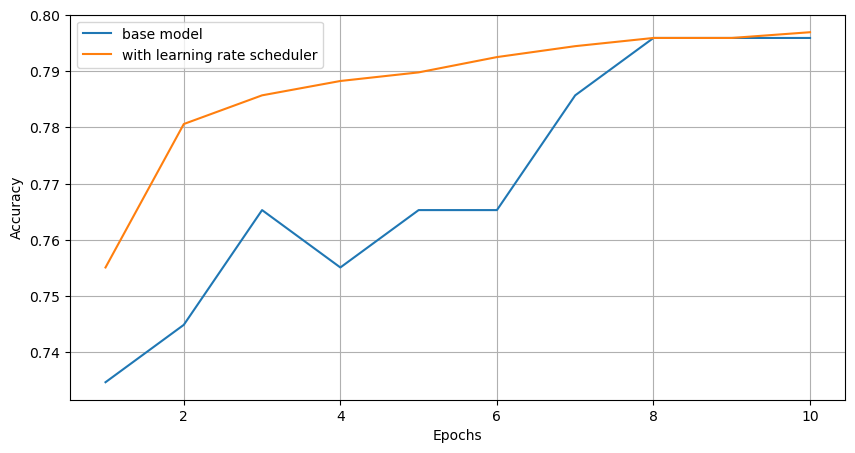

In [891]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), accuracy_hist8, label='base model')
plt.plot(range(1, 11), sch_accuracy_hist, label='with learning rate scheduler')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

2. Batch normalization

In [892]:
class NewNet1(nn.Module):
    def __init__(self):
        super(NewNet1, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.bn1 = nn.BatchNorm1d(64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output

In [893]:
new_net1 = NewNet1()
new_optimizer = optim.SGD(net0.parameters(), lr=0.003)
bn_accracy_hist, bn_loss_hist = train_test_model(new_net1, new_optimizer, train_loader, val_loader, test_loader)

Accuracy: 0.4343, Test Loss: 0.7106, Training Time: 1.1851


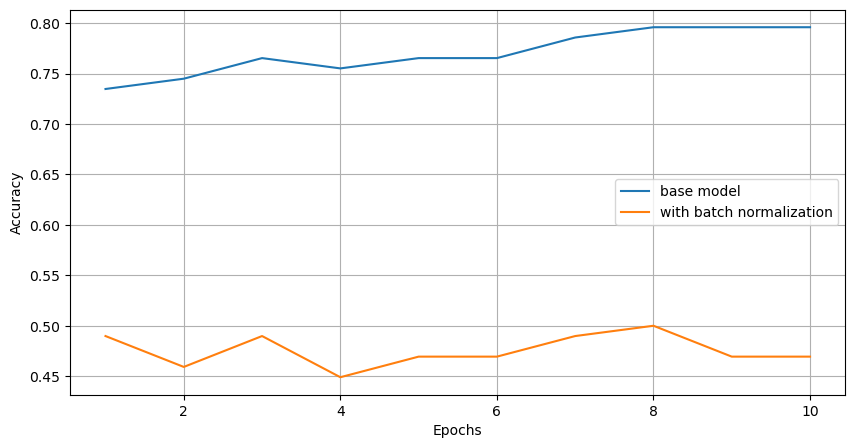

In [897]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), accuracy_hist8, label='base model')
plt.plot(range(1, 11), bn_accracy_hist, label='with batch normalization')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

3. Early stopping

In [598]:
def score_function(engine):
    val_loss = engine.state.metrics['val_loss']
    return -val_loss

In [599]:
model = Net0()
es_optimizer = optim.SGD(model.parameters(), lr=0.003)
es_accuracy_hist = []

In [600]:
def train_en(engine, batch):
    model.train()
    es_optimizer.zero_grad()
    x, y = batch
    y_pred = model(x)
    loss = loss_function(y_pred, y)
    loss.backward()
    es_optimizer.step()
    return loss.item()

In [601]:
def validation_en(engine, batch):
    model.eval()
    with torch.no_grad():
        x, y = batch
        y_output = model(x)
    return y_output, y

In [602]:
trainer = Engine(train_en)
evaluator = Engine(validation_en)
Loss(loss_function).attach(evaluator, "val_loss")
Accuracy(output_transform=lambda output: (torch.round(output[0]), output[1])).attach(evaluator, "val_accuracy")
handler = EarlyStopping(patience=2, score_function=score_function, trainer=trainer)
evaluator.add_event_handler(Events.COMPLETED, handler)

In [603]:
@trainer.on(Events.EPOCH_COMPLETED)
def run_validation():
    evaluator.run(val_loader)
    es_accuracy_hist.append(evaluator.state.metrics['val_accuracy'])
train_state = trainer.run(train_loader, max_epochs=100)

2024-10-26 23:09:43,671 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


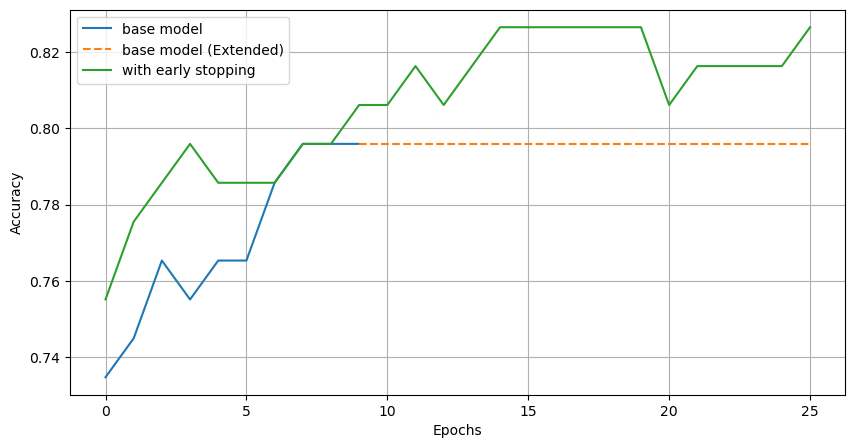

In [896]:
base_accuracy_hist = accuracy_hist8+[accuracy_hist8[-1] for i in range(len(es_accuracy_hist)-len(accuracy_hist8))]
plt.figure(figsize=(10, 5))
plt.plot(accuracy_hist8, label='base model')
plt.plot(range(len(accuracy_hist8)-1, len(es_accuracy_hist)), base_accuracy_hist[len(accuracy_hist8)-1:], '--', label='base model (Extended)')
plt.plot(es_accuracy_hist, label='with early stopping')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

4. k-fold

In [712]:
X_train_kf, X_test_kf, y_train_kf, y_test_kf = train_test_split(X_resampled, y_resampled, test_size = 0.1 , random_state=42)
# Scale numerical variables
scaler = StandardScaler()
scaler.fit(X_train_kf[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_train_kf[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_train_kf[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])
X_test_kf[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']] = scaler.transform(X_test_kf[['f2', 'f3', 'f4', 'f5', 'f6', 'f7']])

X_test_kf = torch.tensor(X_test_kf.values, dtype=torch.float32)
y_test_kf = torch.tensor(y_test_kf.values, dtype=torch.float32)

kf_test_dataset = TensorDataset(X_test_kf, y_test_kf.view(-1, 1))
kf_test_loader = DataLoader(kf_test_dataset, batch_size=4)

In [719]:
k = 10
kf = KFold(n_splits=k, shuffle=True, random_state=42)
kf_val_accuracy_hist = [[] for i in range(k)]
kf_accuracy = []

In [720]:
best_train_idx = []
best_val_idx = []

In [721]:
for i, (train_idx, val_idx) in enumerate(kf.split(X_train_kf)):
    kf_model = Net0()
    kf_optimizer = optim.SGD(kf_model.parameters(), lr=0.003)

    X_kf = torch.tensor(X_train_kf.values, dtype=torch.float32)
    y_kf = torch.tensor(y_train_kf.values, dtype=torch.float32)
    dataset = TensorDataset(X_kf, y_kf.view(-1, 1))
    train_subset = Subset(dataset, train_idx)
    val_subset = Subset(dataset, val_idx)
    
    kf_train_loader = DataLoader(train_subset, batch_size=4, shuffle=True)
    kf_val_loader = DataLoader(val_subset, batch_size=4, shuffle=False)

    accuracy_metric = BinaryAccuracy()
    best_loss = float('inf')
    best_accuracy = 0
    PATH = "best_loss.pt"
    for epoch in range(10):
        # train
        kf_model.train()
        for train_inputs, train_labels in kf_train_loader:
            kf_optimizer.zero_grad()
            outputs = kf_model(train_inputs)
            loss = loss_function(outputs, train_labels)
            loss.backward()
            kf_optimizer.step()
        # validation
        kf_model.eval()
        val_loss = 0
        val_accuracy_metric = BinaryAccuracy()
        with torch.no_grad():
            for val_inputs, val_labels in kf_val_loader:
                val_outputs = kf_model(val_inputs)
                val_predicted = torch.round(val_outputs)
                val_accuracy_metric.update(val_predicted, val_labels)
                val_loss += loss_function(val_outputs, val_labels).item()

        kf_val_accuracy_hist[i].append(val_accuracy_metric.compute().item())
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(kf_model.state_dict(), PATH)

    # test
    kf_model.load_state_dict(torch.load(PATH, weights_only=True))
    with torch.no_grad():
        for test_inputs, test_labels in kf_test_loader:
            test_outputs = kf_model(test_inputs)
            test_predicted = torch.round(test_outputs)
            loss = loss_function(test_outputs, test_labels)
            accuracy_metric.update(test_predicted, test_labels)
    tmp_accuracy = accuracy_metric.compute().item()
    kf_accuracy.append(tmp_accuracy)
    if tmp_accuracy >  best_accuracy:
        best_accuracy = tmp_accuracy
        best_train_idx, best_val_idx = train_idx, val_idx

average_accuracy = sum(kf_accuracy) / k
print(f"\nAverage k-Fold Accuracy: {average_accuracy:.4f}")


Average k-Fold Accuracy: 0.7667


In [906]:
kf_accuracy_hist = np.mean(kf_val_accuracy_hist, axis=0)

In [723]:
kf_accuracy

[0.7878788113594055,
 0.7676767706871033,
 0.747474730014801,
 0.7979797720909119,
 0.7676767706871033,
 0.747474730014801,
 0.747474730014801,
 0.7676767706871033,
 0.7373737096786499,
 0.7979797720909119]

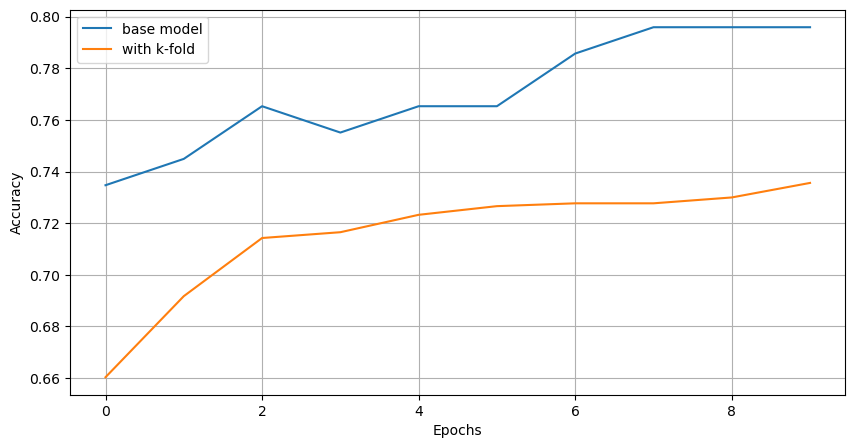

In [907]:
plt.figure(figsize=(10, 5))
plt.plot(accuracy_hist8, label='base model')
plt.plot(kf_accuracy_hist, label='with k-fold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Final NN model
- learning rate 0.003
- apply early stopping

In [1344]:
class BestModel(nn.Module):
    def __init__(self):
        super(BestModel, self).__init__()
        
        self.fc1 = nn.Linear(23, 64)
        self.elu1 = nn.ELU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.fc2 = nn.Linear(64, 128)
        self.elu2 = nn.ELU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.elu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.elu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        output = self.sigmoid(x)
        return output

In [1384]:
best_model = BestModel()
best_optimizer = optim.SGD(best_model.parameters(), lr=0.003)
best_accuracy_hist = []
best_loss_hist = []
best_val_loss = float('inf')
best_model_state = None
BEST_PATH = 'heejuhwa_assignment2_part_2.pt'

In [1385]:
def train_best(engine, batch):
    best_model.train()
    best_optimizer.zero_grad()
    x, y = batch
    y_pred = best_model(x)
    loss = loss_function(y_pred, y)
    loss.backward()
    best_optimizer.step()
    return loss.item()

In [1386]:
def validation_best(engine, batch):
    best_model.eval()
    with torch.no_grad():
        x, y = batch
        y_output = best_model(x)
    return y_output, y

In [1387]:
best_trainer = Engine(train_best)
best_evaluator = Engine(validation_best)
Loss(loss_function).attach(best_evaluator, "val_loss")
Accuracy(output_transform=lambda output: (torch.round(output[0]), output[1])).attach(best_evaluator, "val_accuracy")
best_handler = EarlyStopping(patience=2, score_function=score_function, trainer=best_trainer)
best_evaluator.add_event_handler(Events.COMPLETED, best_handler)

In [1388]:
@best_trainer.on(Events.EPOCH_COMPLETED)
def run_validation():
    global best_val_loss, best_model_state
    best_evaluator.run(val_loader)
    best_accuracy_hist.append(best_evaluator.state.metrics['val_accuracy'])

    val_loss = best_evaluator.state.metrics['val_loss']
    best_loss_hist.append(val_loss)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = best_model.state_dict()
@best_trainer.on(Events.COMPLETED)
def save_best_model():
    global best_model_state
    torch.save(best_model_state, BEST_PATH)
train_state = best_trainer.run(train_loader, max_epochs=100)

2024-10-27 17:28:45,027 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


In [1322]:
def test_model(model, test_loader):
    model.eval()
    all_labels = torch.tensor([])
    all_outputs = torch.tensor([])
    all_preds = torch.tensor([])
    bcm = BinaryConfusionMatrix()
    broc = BinaryROC(thresholds=5)
    test_loss = 0.0

    with torch.no_grad():
        for test_inputs, test_labels in test_loader:
            test_outputs = model(test_inputs)
            test_predicted = torch.round(test_outputs)

            loss = loss_function(test_outputs, test_labels)
            test_loss += loss.item()
            all_labels = torch.cat((all_labels, test_labels), dim=0)
            all_preds = torch.cat((all_preds, test_predicted), dim=0)
            all_outputs = torch.cat((all_outputs, test_outputs), dim=0)

    metric = bcm(all_preds, all_labels)
    tn = metric[0, 0].item()
    fp = metric[0, 1].item()
    fn = metric[1, 0].item()
    tp = metric[1, 1].item()
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    # fpr, tpr, thresholds = broc(all_preds, all_labels)

    # Print the results
    print(f'Accuracy: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1 Score: {2 * (precision * recall) / (precision + recall):.4f}')
    print(f'Test Loss: {test_loss / len(test_loader):.4f}')

    return accuracy, test_loss / len(test_loader), metric, all_outputs, all_labels

In [1389]:
best_model = BestModel()
best_model.load_state_dict(torch.load(BEST_PATH, weights_only=True))
test_accuracy, test_loss, metric, preds, labels = test_model(best_model, test_loader)

Accuracy: 0.7980
Precision: 0.8235
Recall: 0.7925
F1 Score: 0.8077
Test Loss: 0.4710


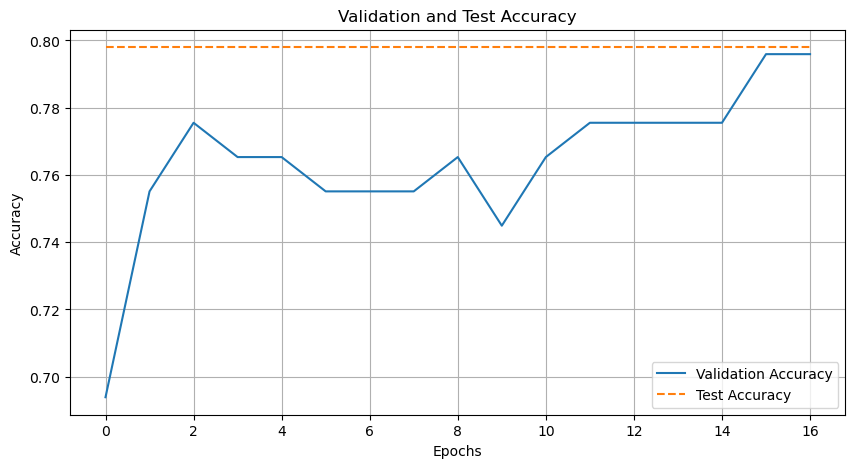

In [1390]:
# Plot accuracies
plt.figure(figsize=(10, 5))
plt.plot(best_accuracy_hist, label='Validation Accuracy')
plt.plot([test_accuracy] * len(best_accuracy_hist), label='Test Accuracy', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Validation and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

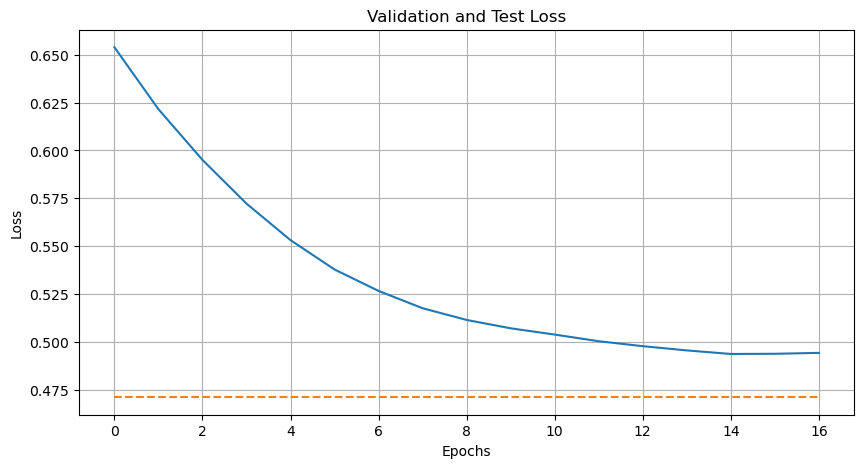

In [1396]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(best_loss_hist, label='Validation Loss')
plt.plot([test_loss] * len(best_loss_hist), label='Test Loss', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Validation and Test Loss')
plt.grid(True)
plt.show()

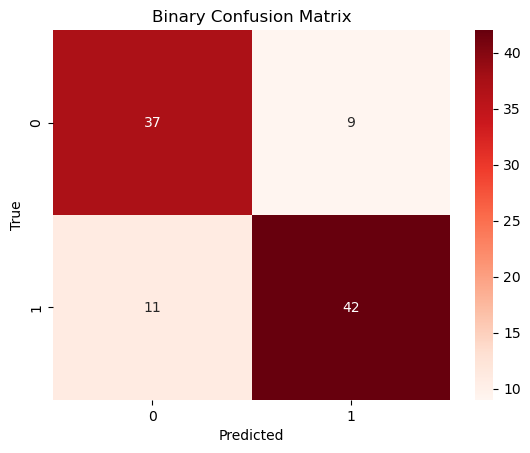

In [1397]:
sns.heatmap(metric.numpy(), annot=True, fmt="d", cmap="Reds", xticklabels=['0', '1'], yticklabels=['0', '1'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Binary Confusion Matrix')
plt.show()

In [1393]:
# ROC curve
roc = BinaryROC()
fpr, tpr, thresholds = roc(preds, labels.to(dtype=torch.long))

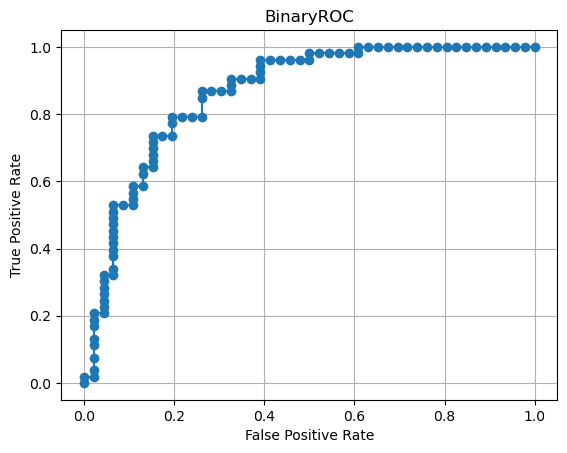

In [1394]:
plt.plot(fpr, tpr, marker='o')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('BinaryROC')
plt.grid()
plt.show()

In [1395]:
summary(best_model)

Layer (type:depth-idx)                   Param #
BestModel                                --
├─Linear: 1-1                            1,536
├─ELU: 1-2                               --
├─Dropout: 1-3                           --
├─Linear: 1-4                            8,320
├─ELU: 1-5                               --
├─Dropout: 1-6                           --
├─Linear: 1-7                            129
├─Sigmoid: 1-8                           --
Total params: 9,985
Trainable params: 9,985
Non-trainable params: 0

### Reference
- Assignment 2 part 1 preprocessing, test
- Quiz 5 PyTorch
- https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.replace.html
- https://scikit-learn.org/1.5/modules/preprocessing.html
- https://scikit-learn.org/dev/modules/generated/sklearn.preprocessing.StandardScaler.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
- https://pytorch.org/docs/stable/nn.html
- https://pytorch.org/tutorials/recipes/recipes/defining_a_neural_network.html
- https://docs.python.org/3/library/time.html
- https://lightning.ai/docs/torchmetrics/stable/classification/accuracy.html
- https://lightning.ai/docs/torchmetrics/stable/classification/roc.html
- https://pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.ReduceLROnPlateau.html
- https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html#batchnorm1d
- https://pytorch.org/ignite/generated/ignite.handlers.early_stopping.EarlyStopping.html
- https://pytorch-ignite.ai/concepts/02-events-and-handlers/
- https://www.geeksforgeeks.org/cross-validation-using-k-fold-with-scikit-learn/
- https://scikit-learn.org/stable/modules/cross_validation.html